In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as prepoc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
%matplotlib inline

### Loading data

In [64]:
data_dir = "../data/train.csv"
df = pd.read_csv(data_dir)

### General Features that describe the house

- BldgType: Type of dwelling
- MSSubClass: Identifies the type of dwelling involved in the sale.
- HouseStyle: Style of dwelling
- Functional: Home functionality (Assume typical unless deductions are warranted)
- OverallQual: Rates the overall material and finish of the house
- OverallCond: Rates the overall condition of the house
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- MiscFeature: Miscellaneous feature not covered in other categories

### Exploring the column values of MSSubClass

In [65]:
df.MSSubClass.unique()

array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

In [66]:
df.MSSubClass.value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

Over 36% of houses are of type: 20	1-STORY 1946 & NEWER ALL STYLES

#### Checking how prices differentiate depending on the type of dwelling involved in the sale

In [67]:
mss_cls_df = pd.concat([df[["MSSubClass"]], df[["SalePrice"]]], axis=1)

In [68]:
avg_price_per_mss_cls = mss_cls_df.groupby("MSSubClass")["SalePrice"].mean().round().reset_index()
avg_price_per_mss_cls = avg_price_per_mss_cls.sort_values("SalePrice")
avg_price_per_mss_cls = avg_price_per_mss_cls.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_mss_cls

,MSSubClass,AvgSalePrice
1,30,95830.0
13,180,102300.0
3,45,108592.0
14,190,129613.0
10,90,133541.0
12,160,138647.0
4,50,143303.0
9,85,147810.0
2,40,156125.0
6,70,166772.0


### Exploring the column values of BldgType

In [69]:
df.BldgType.unique()

array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], dtype=object)

In [70]:
df.BldgType.value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

Over 83% of houses have Single-family Detached Type of dwelling

#### Checking how prices differentiate depending on Type of dwelling

In [71]:
bld_type_df = pd.concat([df[["BldgType"]], df[["SalePrice"]]], axis=1)

In [72]:
avg_price_per_bld_type = bld_type_df.groupby("BldgType")["SalePrice"].mean().round().reset_index()
avg_price_per_bld_type = avg_price_per_bld_type.sort_values("SalePrice")
avg_price_per_bld_type = avg_price_per_bld_type.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_bld_type

,BldgType,AvgSalePrice
1,2fmCon,128432.0
2,Duplex,133541.0
3,Twnhs,135912.0
4,TwnhsE,181959.0
0,1Fam,185764.0


### Exploring the column values of HouseStyle

In [73]:
df.HouseStyle.unique()

array(['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf',
       '2.5Fin'], dtype=object)

In [74]:
df.HouseStyle.value_counts()

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

Over 49% of houses are One story buildings

#### Checking how prices differentiate depending on Style of dwelling

In [75]:
house_style_df = pd.concat([df[["HouseStyle"]], df[["SalePrice"]]], axis=1)

In [76]:
avg_price_per_house_style = house_style_df.groupby("HouseStyle")["SalePrice"].mean().round().reset_index()
avg_price_per_house_style = avg_price_per_house_style.sort_values("SalePrice")
avg_price_per_house_style = avg_price_per_house_style.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_house_style

,HouseStyle,AvgSalePrice
1,1.5Unf,110150.0
6,SFoyer,135074.0
0,1.5Fin,143117.0
4,2.5Unf,157355.0
7,SLvl,166703.0
2,1Story,175985.0
5,2Story,210052.0
3,2.5Fin,220000.0


### Exploring the column values of Functional

In [77]:
df.Functional.unique()

array(['Typ', 'Min1', 'Maj1', 'Min2', 'Mod', 'Maj2', 'Sev'], dtype=object)

In [78]:
df.Functional.value_counts()

Functional
Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: count, dtype: int64

Over 93% of houses have a Typical Functionality

#### Checking how prices differentiate depending on Home functionality

In [79]:
funcitonality_df = pd.concat([df[["Functional"]], df[["SalePrice"]]], axis=1)

In [80]:
avg_price_per_func = funcitonality_df.groupby("Functional")["SalePrice"].mean().round().reset_index()
avg_price_per_func = avg_price_per_func.sort_values("SalePrice")
avg_price_per_func = avg_price_per_func.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_func

,Functional,AvgSalePrice
1,Maj2,85800.0
5,Sev,129000.0
3,Min2,144241.0
2,Min1,146385.0
0,Maj1,153948.0
4,Mod,168393.0
6,Typ,183429.0


### Exploring the column values of OverallQual

In [81]:
df.OverallQual.unique()

array([ 7,  6,  8,  5,  9,  4, 10,  3,  1,  2])

In [82]:
df.OverallQual.value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

#### Checking how prices differentiate depending on Rates of the overall material and finish of the house

In [83]:
overall_qual_df = pd.concat([df[["OverallQual"]], df[["SalePrice"]]], axis=1)

In [84]:
avg_price_per_overall_qual = overall_qual_df.groupby("OverallQual")["SalePrice"].mean().round().reset_index()
avg_price_per_overall_qual = avg_price_per_overall_qual.sort_values("SalePrice")
avg_price_per_overall_qual = avg_price_per_overall_qual.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_overall_qual

,OverallQual,AvgSalePrice
0,1,50150.0
1,2,51770.0
2,3,87474.0
3,4,108421.0
4,5,133523.0
5,6,161603.0
6,7,207716.0
7,8,274736.0
8,9,367513.0
9,10,438588.0


### Exploring the column values of OverallCond

In [85]:
df.OverallCond.unique()

array([5, 8, 6, 7, 4, 2, 3, 9, 1])

In [86]:
df.OverallCond.value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

Over 56% of houses have Average Rates of the overall condition of the house

#### Checking how prices differentiate depending on Rates of the overall condition of the house

In [87]:
overall_cond_df = pd.concat([df[["OverallCond"]], df[["SalePrice"]]], axis=1)

In [88]:
avg_price_per_overall_cond = overall_cond_df.groupby("OverallCond")["SalePrice"].mean().round().reset_index()
avg_price_per_overall_cond = avg_price_per_overall_cond.sort_values("SalePrice")
avg_price_per_overall_cond = avg_price_per_overall_cond.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_overall_cond

,OverallCond,AvgSalePrice
0,1,61000.0
2,3,101929.0
3,4,120438.0
1,2,141986.0
5,6,153962.0
7,8,155652.0
6,7,158145.0
4,5,203147.0
8,9,216005.0


### Exploring the column values of YearBuilt

In [89]:
df.YearBuilt.describe()

count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [90]:
n_nan = df.YearBuilt.isna().sum().item()
print(f"Number of nans in YearBuilt: {n_nan}")

Number of nans in YearBuilt: 0


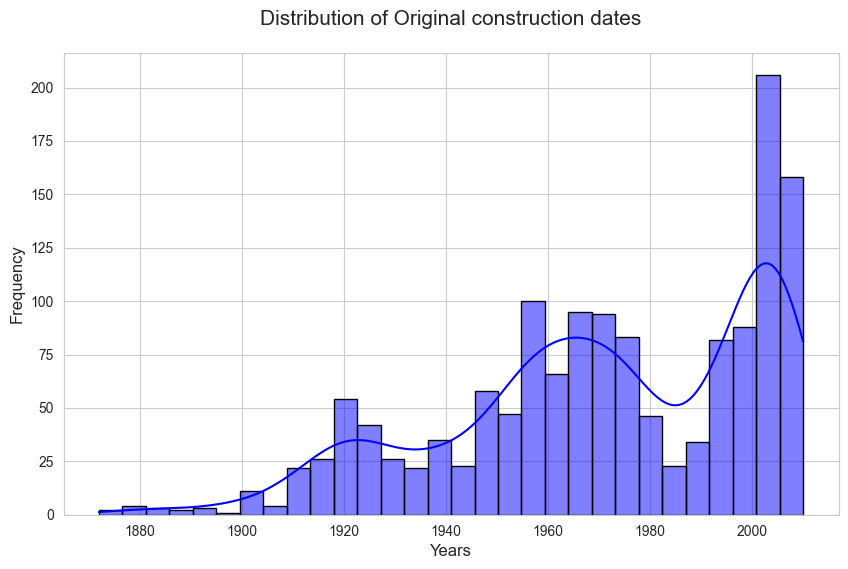

In [91]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['YearBuilt'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Original construction dates", fontsize=15, pad=20)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of YearRemodAdd

In [92]:
df.YearRemodAdd.describe()

count    1460.000000
mean     1984.865753
std        20.645407
min      1950.000000
25%      1967.000000
50%      1994.000000
75%      2004.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64

In [93]:
n_nan = df.YearRemodAdd.isna().sum().item()
print(f"Number of nans in YearRemodAdd: {n_nan}")

Number of nans in YearRemodAdd: 0


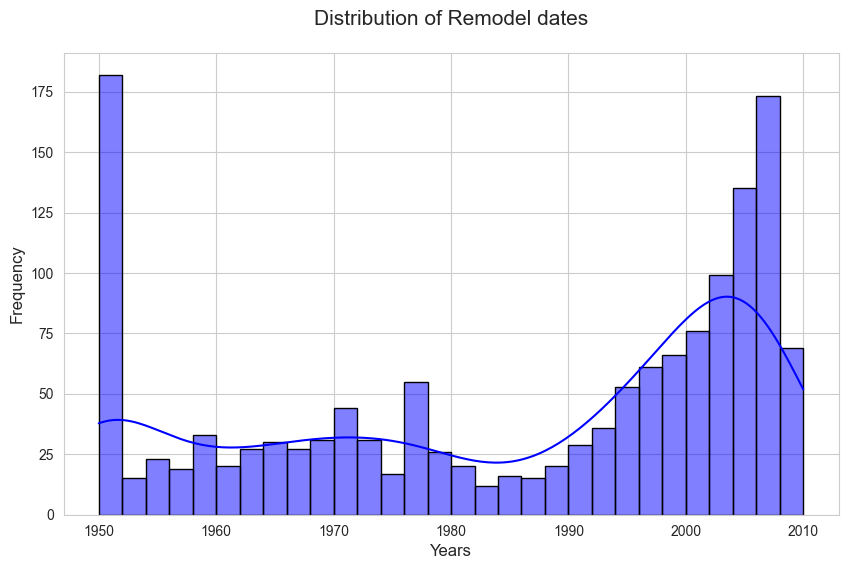

In [94]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['YearRemodAdd'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Remodel dates", fontsize=15, pad=20)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of 1stFlrSF

In [95]:
df[["1stFlrSF"]].describe()

,1stFlrSF
count,1460.000000
mean,1162.626712
std,386.587738
min,334.000000
25%,882.000000
50%,1087.000000
75%,1391.250000
max,4692.000000


In [96]:
n_nan = df[["1stFlrSF"]].isna().sum().item()
print(f"Number of nans in 1stFlrSF: {n_nan}")

Number of nans in 1stFlrSF: 0


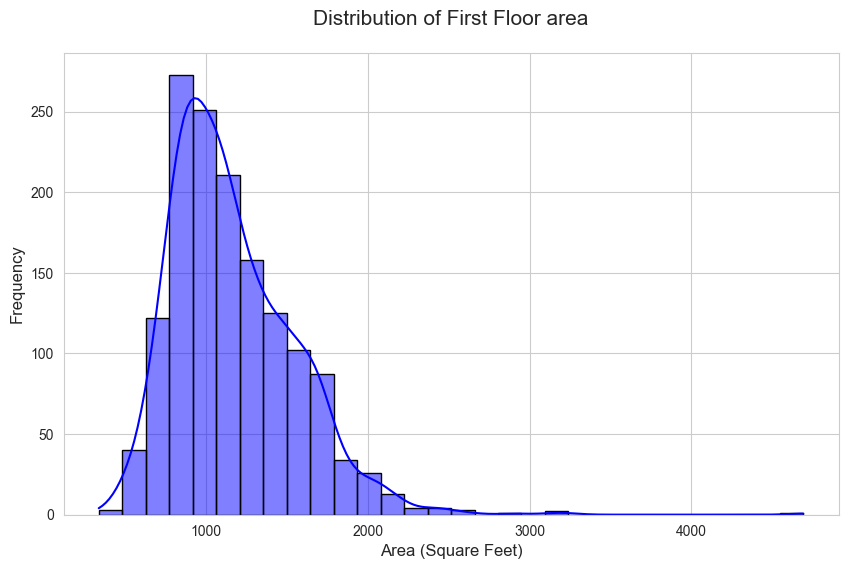

In [97]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['1stFlrSF'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of First Floor area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of 2ndFlrSF

In [98]:
df[["2ndFlrSF"]].describe()

,2ndFlrSF
count,1460.000000
mean,346.992466
std,436.528436
min,0.000000
25%,0.000000
50%,0.000000
75%,728.000000
max,2065.000000


In [99]:
n_nan = df[["2ndFlrSF"]].isna().sum().item()
print(f"Number of nans in 2ndFlrSF: {n_nan}")

Number of nans in 2ndFlrSF: 0


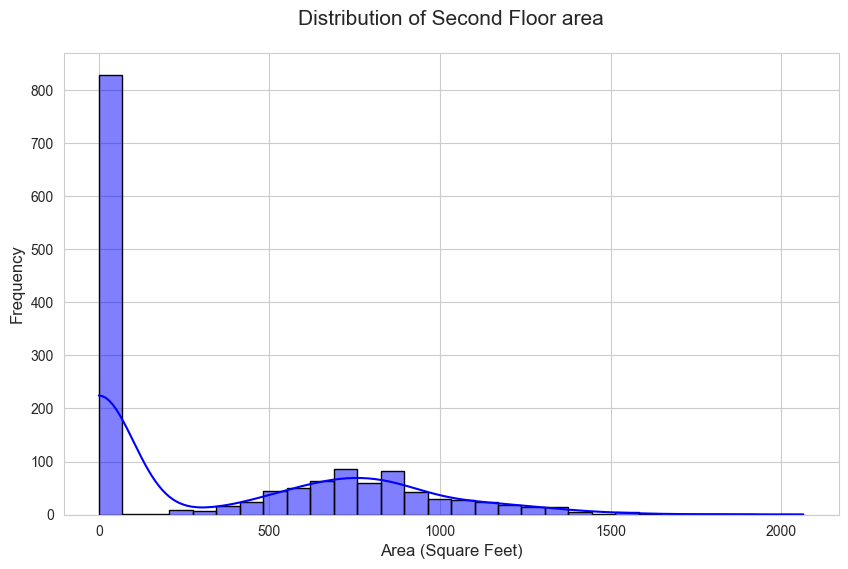

In [100]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['2ndFlrSF'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Second Floor area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of LowQualFinSF

In [101]:
df.LowQualFinSF.describe()

count    1460.000000
mean        5.844521
std        48.623081
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       572.000000
Name: LowQualFinSF, dtype: float64

In [102]:
n_nan = df.LowQualFinSF.isna().sum().item()
print(f"Number of nans in LowQualFinSF: {n_nan}")

Number of nans in LowQualFinSF: 0


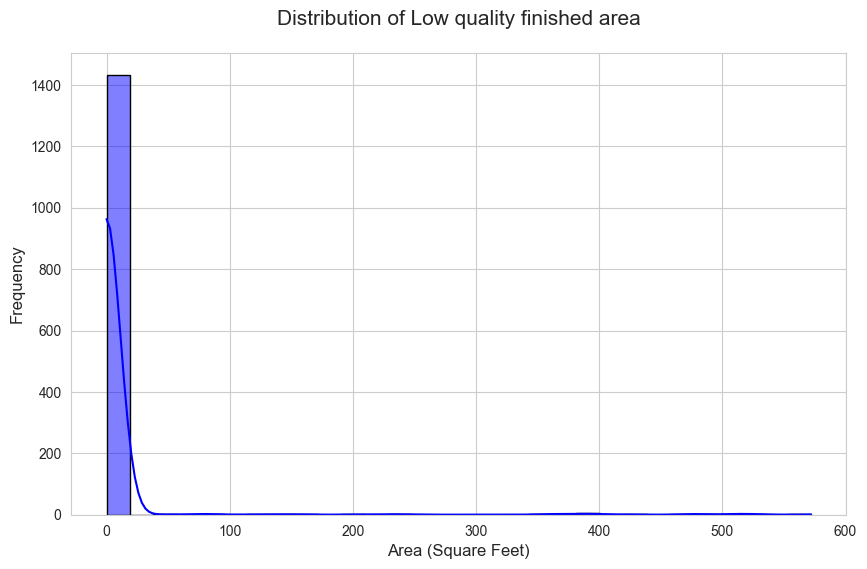

In [103]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['LowQualFinSF'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Low quality finished area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of GrLivArea

In [104]:
df.GrLivArea.describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

In [105]:
n_nan = df.GrLivArea.isna().sum().item()
print(f"Number of nans in GrLivArea: {n_nan}")

Number of nans in GrLivArea: 0


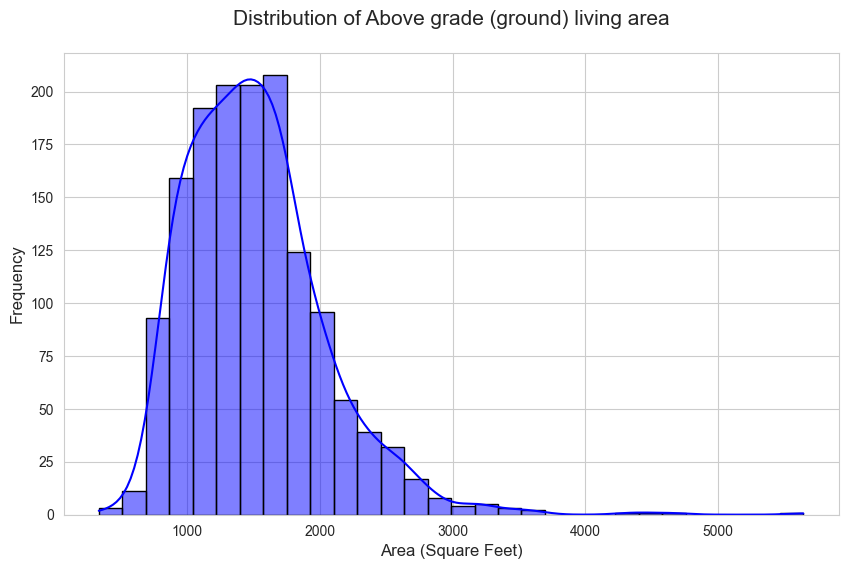

In [106]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['GrLivArea'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Above grade (ground) living area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of MiscFeature

In [107]:
df.MiscFeature.unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [108]:
df.MiscFeature.value_counts()

MiscFeature
Shed    49
Gar2     2
Othr     2
TenC     1
Name: count, dtype: int64

Over 96% of houses have no miscellaneous feature

#### Checking how prices differentiate depending on the MiscFeature

In [109]:
misc_feature_series = df.MiscFeature.apply(lambda x: "No feature" if pd.isna(x) else x)
misc_feature_df = pd.DataFrame(misc_feature_series.values, columns=["MiscFeature"])
misc_feature_df.value_counts()

MiscFeature
No feature     1406
Shed             49
Gar2              2
Othr              2
TenC              1
Name: count, dtype: int64

In [110]:
misc_feature_df = pd.concat([misc_feature_df, df[["SalePrice"]]], axis=1)

In [111]:
avg_price_per_feature = misc_feature_df.groupby("MiscFeature")["SalePrice"].mean().round().reset_index()
avg_price_per_feature = avg_price_per_feature.sort_values("SalePrice")
avg_price_per_feature = avg_price_per_feature.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_feature

,MiscFeature,AvgSalePrice
2,Othr,94000.0
3,Shed,151188.0
0,Gar2,170750.0
1,No feature,182046.0
4,TenC,250000.0


As can be seen the highest avg price have the houses with Tennis Court while houses with no features have the second highest avg price

If there were more samples with tennis courts - we could create a separate binary feature, since the price of such house is distinctively high, but since there is only one sample with tennis court - we will omit such proceeding

It is reasonable to transform MiscFeature column into a binary feature that determines whether house has one of the miscellaneous features or not.

### The correlation matrix of non-categorical fatures and the sale price(before transformations)

Non-categorical features:
- YearBuilt
- YearRemodAdd
- 1stFlrSF
- 2ndFlrSF
- LowQualFinSF
- GrLivArea

In [112]:
df_num = df[["YearBuilt", "YearRemodAdd", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "SalePrice"]]

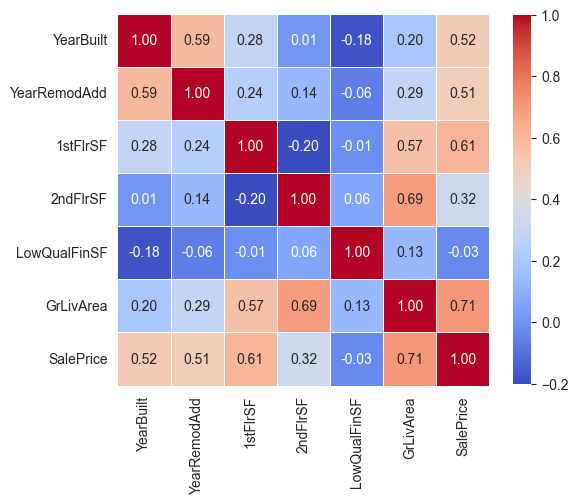

In [113]:
corr_matrix = df_num.corr()
plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, cbar_kws={"shrink": .8}, square=True)
plt.show()

Primary Conclusions:
1. GrLivArea and 1stFlrSF have a strong positive correlation with the SalePrice
2. YearBuilt and YearRemodAdd have a moderetely strong positive correlation with the SalePrice
3. 2ndFlrSF has a rather weak positive correlation with the SalePrice
4. LowQualFinSF has a very weak negative correlation with the SalePrice and can be regarded as redundant
5. Since YearBuilt and YearRemodAdd are the same if no remodeling or additions were done - YearRemodAdd may be redundant
6. Since GrLivArea is a sub-area of a 1stFlrSF - we see a pretty strong positive correlation between these features